In [7]:
import os
import glob
import json
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel, Field
from typing import Literal


In [8]:
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [9]:
pdf_files = glob.glob('*.pdf')
if not pdf_files:
    raise FileNotFoundError("No PDF found! Place a .pdf file in this folder.")

pdf_path = pdf_files[0]
print(f"Using PDF: {pdf_path}")

loader = PyPDFLoader(pdf_path)
docs = loader.load()

print(f"Loaded {len(docs)} pages")

Using PDF: DataMiningTextbook.pdf
Loaded 740 pages


In [10]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

print(f"Split into {len(chunks)} chunks")

Split into 2598 chunks


In [11]:
# FAISS -> Facebook AI Similarity Search Vector Store
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 4})
print("Vector store ready")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6740.41it/s]


Vector store ready


In [12]:
class RAGState(TypedDict):
    question: str       # the user's original question
    documents: list     # retrieved document chunks (kept only if relevant)
    generation: str     # final generated answer
    retry_count: int    # how many times we've rewritten (prevents infinite loops)
    trace: list         # execution trace — records which nodes were visited

In [13]:
class GradeSchema(BaseModel):
    score: Literal["relevant", "irrelevant"] = Field(
        description="Is the retrieved document relevant to the question?"
        )

grader = model.with_structured_output(GradeSchema)

def grade_one_document(question: str, doc_content: str) -> bool:
    """Ask the LLM if a single document chunk is relevant. Returns True/False."""
    prompt = f"""You are a relevance grader. Does this document contain information useful for answering the question?
    Document:{doc_content}
    Question: {question}
    Score as 'relevant' or 'irrelevant'."""
    result = grader.invoke(prompt)
    return result.score == "relevant"

# Quick test — should print True or False
test = grade_one_document("What is data mining?", "Data mining is the process of discovering patterns in large datasets.")
print(f"Grader test: {test}")


Grader test: True


In [14]:
def retrieve(state: RAGState):
    """Node 1: Retrieve top-k documents from FAISS."""
    question = state['question']
    documents = retriever.invoke(question)
    trace = state.get('trace', []) + ['retrieve']
    print(f"  [retrieve] Found {len(documents)} chunks for: {question[:60]}")
    return {'documents': documents, 'trace': trace}


def grade_documents(state: RAGState):
    """Node 2: Grade each retrieved document. Keep only relevant ones."""
    question = state['question']
    documents = state['documents']

    relevant_docs = []
    for doc in documents:
        if grade_one_document(question, doc.page_content):
            relevant_docs.append(doc)

    trace = state.get('trace', []) + ['grade_documents']
    print(f"  [grade] {len(relevant_docs)}/{len(documents)} chunks marked relevant")
    return {'documents': relevant_docs, 'trace': trace}


def rewrite_query(state: RAGState):
    """Node 3: Rewrite the question for better retrieval."""
    question = state['question']
    prompt = f"""The following question did not retrieve good results from a document database. Rewrite it to be more specific and search-friendly. Output ONLY the rewritten question, nothing else.

Original question: {question}"""
    response = model.invoke(prompt)
    new_question = response.content.strip()
    trace = state.get('trace', []) + ['rewrite_query']
    print(f"  [rewrite] '{question[:50]}' -> '{new_question[:50]}'")
    return {'question': new_question, 'retry_count': state.get('retry_count', 0) + 1, 'trace': trace}


def generate(state: RAGState):
    """Node 4: Generate answer from the retrieved (and graded) documents."""
    question = state['question']
    documents = state['documents']
    trace = state.get('trace', []) + ['generate']

    if not documents:
        return {'generation': 'I could not find relevant information in the PDF to answer this question.', 'trace': trace}

    context = "\n\n".join([doc.page_content for doc in documents])

    prompt = f"""Answer the question based ONLY on the following context. If the context doesn't contain enough information, say so clearly.

Context:
{context}

Question: {question}"""
    response = model.invoke(prompt)
    return {'generation': response.content, 'trace': trace}


### PDF-Only Self-Correcting RAG

If retrieved docs are irrelevant → rewrite the query → re-retrieve from the same PDF.
```

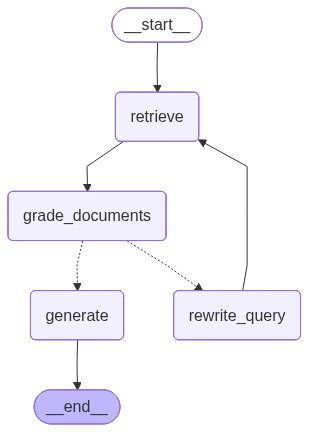

In [15]:
def decide_after_grading_v1(state: RAGState) -> str:
    """Route after grading: generate if we have docs OR already retried once."""
    if state['documents']:
        return 'generate'
    elif state.get('retry_count', 0) >= 1:
        return 'generate'  # give up gracefully after 1 retry
    else:
        return 'rewrite_query'


graph_v1 = StateGraph(RAGState)

graph_v1.add_node('retrieve', retrieve)
graph_v1.add_node('grade_documents', grade_documents)
graph_v1.add_node('rewrite_query', rewrite_query)
graph_v1.add_node('generate', generate)

graph_v1.add_edge(START, 'retrieve')
graph_v1.add_edge('retrieve', 'grade_documents')
graph_v1.add_conditional_edges('grade_documents', decide_after_grading_v1, {
    'generate': 'generate',
    'rewrite_query': 'rewrite_query'
})
graph_v1.add_edge('rewrite_query', 'retrieve')  # loop back to try again
graph_v1.add_edge('generate', END)

variant_1 = graph_v1.compile()
variant_1

### Test 

In [ ]:
# Question IN the PDF 
result = variant_1.invoke({
    'question': 'What is association rule mining?',
    'retry_count': 0,
    'trace': []
})

print("\n" + "="*60)
print("EXECUTION TRACE:", " → ".join(result['trace']))
print("Question:", result['question'])
print(f"Documents found: {len(result['documents'])}")
print("\nAnswer:", result['generation'])

  [retrieve] Found 4 chunks for: What is association rule mining?
  [grade] 4/4 chunks marked relevant

EXECUTION TRACE: retrieve → grade_documents → generate
Question: What is association rule mining?
Documents found: 4

Answer: Association rule mining is a two-step process consisting of: 
1. Frequent itemset mining: searching for patterns of attribute-value pairs that occur repeatedly in a data set.
2. Rule generation: analyzing the frequent itemsets to generate association rules that satisfy certain criteria regarding their "accuracy" (or confidence) and the proportion of the data set that they actually represent (referred to as support).


In [ ]:
# Question NOT in the PDF 
result = variant_1.invoke({
    'question': 'What is the capital of France?',
    'retry_count': 0,
    'trace': []
})

print("\n" + "="*60)
print("EXECUTION TRACE:", " → ".join(result['trace']))
print("Question (possibly rewritten):", result['question'])
print(f"Documents found: {len(result['documents'])}")
print("\nAnswer:", result['generation'])

  [retrieve] Found 4 chunks for: What is the capital of France?
  [grade] 0/4 chunks marked relevant
  [rewrite] 'What is the capital of France?' -> 'What is the capital city of the country France in '
  [retrieve] Found 4 chunks for: What is the capital city of the country France in Europe?
  [grade] 0/4 chunks marked relevant

EXECUTION TRACE: retrieve → grade_documents → rewrite_query → retrieve → grade_documents → generate
Question (possibly rewritten): What is the capital city of the country France in Europe?
Documents found: 0

Answer: I could not find relevant information in the PDF to answer this question.


### Web Fallback Self-Correcting RAG

If retrieved docs are irrelevant → rewrite the query → search DuckDuckGo → generate from web results.

```

In [ ]:
from ddgs import DDGS


def web_search(state: RAGState):
    """Fallback node: search DuckDuckGo when the PDF doesn't have the answer."""
    question = state['question']

    with DDGS() as ddgs:
        results = ddgs.text(question, max_results=3)

    web_docs = []
    for r in results:
        content = f"{r['title']}\n{r['body']}"
        web_docs.append(Document(page_content=content, metadata={'source': r['href']}))

    trace = state.get('trace', []) + ['web_search']
    print(f"  [web_search] Found {len(web_docs)} web results")
    return {'documents': web_docs, 'trace': trace}


def generate_with_sources(state: RAGState):
    """Generate answer and cite which source each piece of info comes from."""
    question = state['question']
    documents = state['documents']
    trace = state.get('trace', []) + ['generate']

    if not documents:
        return {'generation': 'I could not find relevant information to answer this question.', 'trace': trace}

    context_parts = []
    for doc in documents:
        source = doc.metadata.get('source', 'PDF')
        context_parts.append(f"[Source: {source}]\n{doc.page_content}")

    context = "\n\n".join(context_parts)

    prompt = f"""Answer the question based ONLY on the following context. Mention which source the information comes from. If the context doesn't have enough info, say so. 
    Context: {context}
    Question: {question}"""
    response = model.invoke(prompt)
    return {'generation': response.content, 'trace': trace}

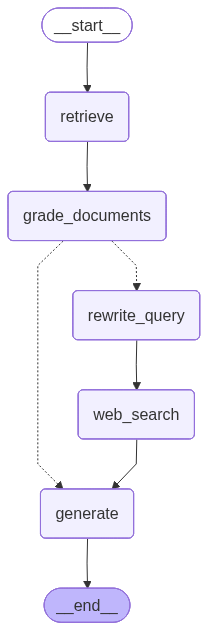

In [19]:
def decide_after_grading_v2(state: RAGState) -> str:
    if state['documents']:
        return 'generate'
    else:
        return 'rewrite_query'


graph_v2 = StateGraph(RAGState)

graph_v2.add_node('retrieve', retrieve)
graph_v2.add_node('grade_documents', grade_documents)
graph_v2.add_node('rewrite_query', rewrite_query)
graph_v2.add_node('web_search', web_search)
graph_v2.add_node('generate', generate_with_sources)

graph_v2.add_edge(START, 'retrieve')
graph_v2.add_edge('retrieve', 'grade_documents')
graph_v2.add_conditional_edges('grade_documents', decide_after_grading_v2, {
    'generate': 'generate',
    'rewrite_query': 'rewrite_query'
})
graph_v2.add_edge('rewrite_query', 'web_search')  # go to web instead of looping!
graph_v2.add_edge('web_search', 'generate')
graph_v2.add_edge('generate', END)

variant_2 = graph_v2.compile()
variant_2

### Test 

In [ ]:
# Question IN the PDF
result = variant_2.invoke({
    'question': 'What is association rule mining?',
    'retry_count': 0,
    'trace': []
})

print("\n" + "="*60)
print("EXECUTION TRACE:", " → ".join(result['trace']))
print("Question:", result['question'])
print(f"Documents found: {len(result['documents'])}")
for doc in result['documents']:
    print(f"  Source: {doc.metadata.get('source', 'PDF')}")
print("\nAnswer:", result['generation'])

  [retrieve] Found 4 chunks for: What is association rule mining?
  [grade] 4/4 chunks marked relevant

EXECUTION TRACE: retrieve → grade_documents → generate
Question: What is association rule mining?
Documents found: 4
  Source: DataMiningTextbook.pdf
  Source: DataMiningTextbook.pdf
  Source: DataMiningTextbook.pdf
  Source: DataMiningTextbook.pdf

Answer: Association rule mining is a two-step process consisting of frequent itemset mining followed by rule generation. The first step searches for patterns of attribute–value pairs that occur repeatedly in a data set, and the second step analyzes the frequent itemsets to generate association rules. These rules must satisfy certain criteria regarding their "accuracy" (or confidence) and the proportion of the data set that they actually represent (referred to as support). (Source: DataMiningTextbook.pdf)


In [ ]:
# Question NOT in the PDF
result = variant_2.invoke({
    'question': 'What is the capital of France?',
    'retry_count': 0,
    'trace': []
})

print("\n" + "="*60)
print("EXECUTION TRACE:", " → ".join(result['trace']))
print("Question (possibly rewritten):", result['question'])
print(f"Documents found: {len(result['documents'])}")
for doc in result['documents']:
    print(f"  Source: {doc.metadata.get('source', 'PDF')}")
print("\nAnswer:", result['generation'])

  [retrieve] Found 4 chunks for: What is the capital of France?
  [grade] 0/4 chunks marked relevant
  [rewrite] 'What is the capital of France?' -> 'What is the capital city of the country France in '
  [web_search] Found 3 web results

EXECUTION TRACE: retrieve → grade_documents → rewrite_query → web_search → generate
Question (possibly rewritten): What is the capital city of the country France in Europe?
Documents found: 3
  Source: https://en.wikipedia.org/wiki/Paris
  Source: https://www.britannica.com/place/France
  Source: https://www.geocountries.com/france

Answer: The capital city of France is Paris. This information comes from multiple sources: 
1. https://en.wikipedia.org/wiki/Paris 
2. https://www.britannica.com/place/France 
3. https://www.geocountries.com/france 

All three sources confirm that Paris is the capital of France.


## Comparison Test

In [ ]:
test_questions = [
    "What is association rule mining?",
    "Explain the concept of clustering in data mining.",
    "What are decision trees?",
    "What is the capital of France?",
    "Who won the FIFA World Cup in 2022?",
]

print(f"Running {len(test_questions)} questions through both variants...")
print("=" * 80)

comparison_results = []

for q in test_questions:
    print(f"\n{'─'*80}")
    print(f"Q: {q}")

    print("\n  --- (PDF-Only) ---")
    r1 = variant_1.invoke({'question': q, 'retry_count': 0, 'trace': []})

    print("\n  --- (Web Fallback) ---")
    r2 = variant_2.invoke({'question': q, 'retry_count': 0, 'trace': []})

    comparison_results.append({
        'question': q,
        'v1_docs': len(r1['documents']),
        'v1_trace': ' → '.join(r1['trace']),
        'v1_answer': r1['generation'][:100] + ('...' if len(r1['generation']) > 100 else ''),
        'v2_docs': len(r2['documents']),
        'v2_trace': ' → '.join(r2['trace']),
        'v2_answer': r2['generation'][:100] + ('...' if len(r2['generation']) > 100 else ''),
    })

Running 5 questions through both variants...

────────────────────────────────────────────────────────────────────────────────
Q: What is association rule mining?

  --- Variant 1 (PDF-Only) ---
  [retrieve] Found 4 chunks for: What is association rule mining?
  [grade] 4/4 chunks marked relevant

  --- Variant 2 (Web Fallback) ---
  [retrieve] Found 4 chunks for: What is association rule mining?
  [grade] 4/4 chunks marked relevant

────────────────────────────────────────────────────────────────────────────────
Q: Explain the concept of clustering in data mining.

  --- Variant 1 (PDF-Only) ---
  [retrieve] Found 4 chunks for: Explain the concept of clustering in data mining.
  [grade] 4/4 chunks marked relevant

  --- Variant 2 (Web Fallback) ---
  [retrieve] Found 4 chunks for: Explain the concept of clustering in data mining.
  [grade] 4/4 chunks marked relevant

────────────────────────────────────────────────────────────────────────────────
Q: What are decision trees?

  --- Var